# Naive Bayes Classifier
Naive Bayes is a classification algorithm based on Bayes' Theorem with an assumption of independence among predictors or features. It is particularly useful for large datasets and is often used in text classification tasks such as spam detection.

## Bayes' Theorem
Bayes' Theorem describes the probability of an event, based on prior knowledge of conditions that might be related to the event. The formula is given by:

```math
p(H|E) = \frac{p(E|H) \cdot p(H)}{p(E)}
```

Where:
- H: Hypothesis (e.g., class label)
- E: Evidence (e.g., features)
- p(H|E): Posterior probability of hypothesis \( H \) given evidence \( E \)
- p(E|H): Likelihood of evidence \( E \) given hypothesis \( H \)
- p(H): Prior probability of hypothesis \( H \)
- p(E): Prior probability that the evidence is true \( E \)

Example: 40 percent of all emails are spam, 20 percent of spam emails contain the word lottery, 2 percent of non spam emails contain the word lottery.\
If an email that  contains the word “lottery”. Calculate: P(spam | lottery)\
Solution: 
$p(Spam)$ = 0.4\
$p(NotSpam)$ = 0.6\
$p(Lottery|Spam)$ = 0.2\
$p(Lottery|NotSpam)$ = 0.02
```math
p(Spam|Lottery) = \frac{p(Lottery|Spam) \cdot p(Spam)}{p(Lottery)}\\
= \frac{p(Lottery|Spam) \cdot p(Spam)}{p(Lottery|Spam) \cdot p(Spam) + p(Lottery|NotSpam) \cdot p(NotSpam)}\\
```
= (0.2 * 0.4) / (0.2 * 0.4 + 0.02 * 0.6) = 0.08 / (0.08 + 0.012) = 0.08 / 0.092 = 0.8696\
So, the probability that the email is spam given that it contains the word "lottery" is approximately 86.96%.

#### Strenghts
- Blazingly fast and efficient, especially for large datasets.
- Lightweight and requires less training data.
- High-demensional data handling capability.
- Shines in NLP tasks like spam detection and sentiment analysis.

#### Limitations
- Unrealistic independence assumption among features.
- Struggles with correlated features.
- Zero probability problem for unseen features in training data.

### The Naive Assumption
The `naive` assumption in Naive Bayes refers to the assumption that all features are independent of each other given the class label. This means that the presence or absence of a particular feature does not affect the presence or absence of any other feature when the class label is known.

```math
p(x_1, x_2, ..., x_n | C) = p(x_1 | C) \cdot p(x_2 | C) \cdot ... \cdot p(x_n | C)
```

Where:
- $x_1, x_2, ..., x_n$ are the features.
- $C$ is the class label.

## Training and Prediction Mechanism
1. Goal of Naive Bayes
    - To find the class $ C $ that maximizes the posterior probability given the features $ X = (x_1, x_2, ..., x_n) $.
    ```math
    \hat{y} = \arg\max_{c \in C} p(c) \prod_{i=1}^{n} p(x_i | c)
    ```
    Where:
    - $\hat{y}$: Predicted class label.
    - $C$: Set of all possible class labels.
    - $p(c)$: Prior probability of class $c$.

2. Training Phase
    - Calculate prior probabilities $ p(c) $ for each class $ c $.
    - Calculate likelihood probabilities $ p(x_i | c) $ for each feature $ x_i $ given class $ c $. But if the likelihood is zero for any feature, it will make the entire product zero. To avoid this, we can use techniques like Laplace smoothing.\
    Laplace Smoothing:
    ```math
    p(x_i | c) = \frac{count(x_i, c) + 1}{count(c) + V}
    ```
    Where:
    - $count(x_i, c)$: Number of times feature $ x_i $ appears in class $ c $.
    - $count(c)$: Total number of instances in class $ c $.
    - $V$: Total number of unique features (vocabulary size).
    So, even if a feature hasn't appeared in the training data for a particular class, it will still have a small, non-zero probability.
3. Prediction Phase
    - For a new instance with features $ X = (x_1, x_2, ..., x_n) $, calculate the posterior probability for each class using the formula:
    ```math
    p(c|X) \propto p(c) \prod_{i=1}^{n} p(x_i | c)
    ```
    - Predict the class with the highest posterior probability.

Example: Suppose we have a dataset with the following features and class labels: $p(spam)=0.4$, $p(not spam)=0.6$, $p(offer|spam)=0.2$, $p(free|spam)=0.10$, $p(offer|not spam)=0.02$, $p(free|not spam)=0.01$\
To classify a new email containing the words "offer" and "free", we calculate the posterior probabilities for both classes:
$p(spam|offer, free) \propto p(spam) \cdot p(offer|spam) \cdot p(free|spam) = 0.4 \cdot 0.2 \cdot 0.10 = 0.008$\
$p(not spam|offer, free) \propto p(not spam) \cdot p(offer|not spam) \cdot p(free|not spam) = 0.6 \cdot 0.02 \cdot 0.01 = 0.00012$\
Since $p(spam|offer, free) > p(not spam|offer, free)$, we classify the email as spam.


## Different Types of Naive Bayes Classifiers
1. Gaussian Naive Bayes
    - Used when features are continuous, numerical, and assumed to follow a Gaussian (normal) distribution.
    - The likelihood of the features is calculated using the Gaussian probability density function.
    - Suitable for datasets where features are real-valued.
2. Multinomial Naive Bayes
    - Used for discrete data, particularly in text classification tasks.
    - Models the distribution of word counts or frequencies in documents.
    - Suitable for datasets where features represent counts or frequencies.
3. Bernoulli Naive Bayes
    - Used for binary/boolean features.
    - Models the presence or absence of a feature rather than its frequency.
    - Suitable for datasets where features are binary-valued.

In [1]:
# Gaussian Naive Bayes
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state=42, stratify=y
)
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

Accuracy: 0.9371
              precision    recall  f1-score   support

   malignant       0.96      0.87      0.91        53
      benign       0.93      0.98      0.95        90

    accuracy                           0.94       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.94      0.94       143



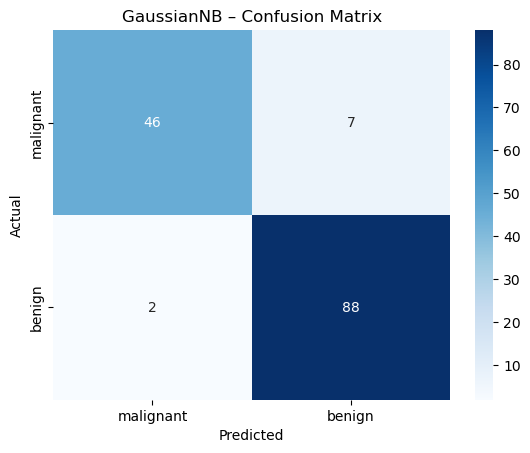

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = gnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('GaussianNB – Confusion Matrix')
plt.show()

In [8]:
# Multinomial Naive Bayes
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

categories = ['comp.graphics', 'rec.sport.baseball', 'sci.med']
newsgroups = fetch_20newsgroups(
    subset = 'train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=42
)
df_news = pd.DataFrame({
    'text': newsgroups.data,
    'label': newsgroups.target
})
df_news.head()

,text,label
0,"\nThe FDA, I believe. Rules say no blood or b...",2
1,,2
2,It would be nice to think that individuals can...,2
3,"Ok all you trivia buffs, I have a good one for...",1
4,"Please , I need the starting address (pointer)...",0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    df_news['text'], df_news['label'], test_size=0.25, random_state=42, stratify=df_news['label']
)   # Stratify to toke equal class in test

vectorizer_news = CountVectorizer(stop_words='english', max_features=3000)      # Limit features to 3000 and stop word to avoid common words like 'is', 'the', 'a' etc.
X_train_counts = vectorizer_news.fit_transform(X_train_text)
X_test_counts = vectorizer_news.transform(X_test_text)

mnb_news = MultinomialNB()
mnb_news.fit(X_train_counts, y_train_text)

MultinomialNB()

Accuracy: 0.9234
                    precision    recall  f1-score   support

     comp.graphics       0.92      0.92      0.92       146
rec.sport.baseball       0.88      0.95      0.92       149
           sci.med       0.97      0.90      0.93       149

          accuracy                           0.92       444
         macro avg       0.93      0.92      0.92       444
      weighted avg       0.93      0.92      0.92       444



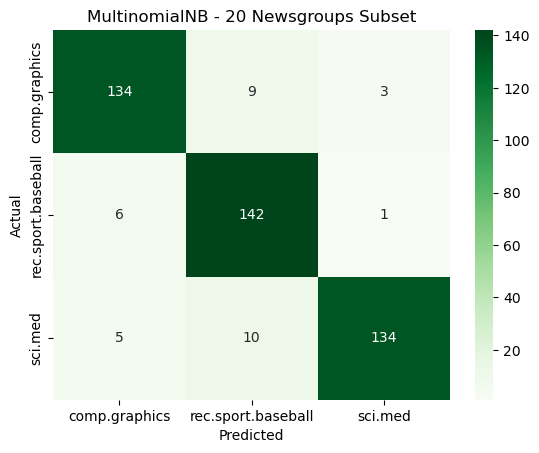

In [14]:
y_news_pred = mnb_news.predict(X_test_counts)
acc_news = accuracy_score(y_test_text, y_news_pred)
print(f"Accuracy: {acc_news:.4f}")
print(classification_report(y_test_text, y_news_pred,
                            target_names=newsgroups.target_names))

cm_news = confusion_matrix(y_test_text, y_news_pred)

sns.heatmap(cm_news, annot=True, fmt='d', cmap='Greens',
            xticklabels=newsgroups.target_names,
            yticklabels=newsgroups.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MultinomialNB - 20 Newsgroups Subset')
plt.show()

In [16]:
# Bernoulli Naive Bayes
from sklearn.naive_bayes import BernoulliNB

vectorizer_bin = CountVectorizer(binary=True)   # binary=True so it counts presence/absence rather than frequency
X_train_bin = vectorizer_bin.fit_transform(X_train_text)
X_test_bin = vectorizer_bin.transform(X_test_text)

bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train_text)

BernoulliNB()

Accuracy: 0.8221
                    precision    recall  f1-score   support

     comp.graphics       0.87      0.86      0.87       146
rec.sport.baseball       0.73      0.99      0.84       149
           sci.med       0.94      0.62      0.74       149

          accuracy                           0.82       444
         macro avg       0.85      0.82      0.82       444
      weighted avg       0.85      0.82      0.82       444



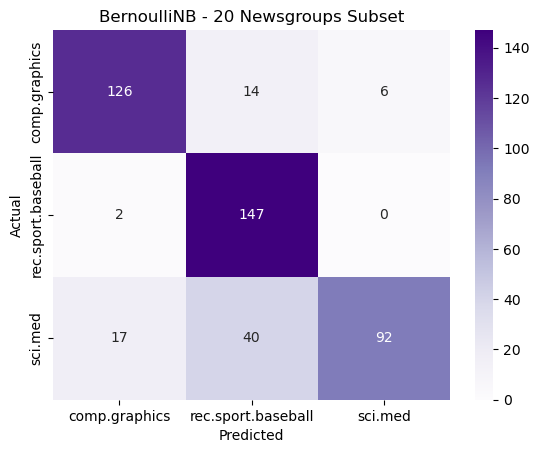

In [17]:
y_pred_bin = bnb.predict(X_test_bin)
acc_bin = accuracy_score(y_test_text, y_pred_bin)
print(f"Accuracy: {acc_bin:.4f}")
print(classification_report(y_test_text, y_pred_bin,
                            target_names=newsgroups.target_names))

cm_bin = confusion_matrix(y_test_text, y_pred_bin)

sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Purples',
            xticklabels=newsgroups.target_names,
            yticklabels=newsgroups.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('BernoulliNB - 20 Newsgroups Subset')
plt.show()